# Amazon Marketplace Product Intelligence Platform
## Data Preparation and Cleaning

This notebook performs the initial data preparation and cleaning of the
Amazon product dataset collected through the project's custom data
collection pipeline.

### Objectives
- Load the raw Amazon product dataset
- Inspect dataset structure and data types
- Identify data quality issues
- Prepare the dataset for downstream analytical features
- Save the cleaned master dataset

### Input
`amazon_products_raw.csv`

### Output
`cleaned_products.csv`

#Section 1 - Data Analysis

In [5]:
#Cell 2 — Import Required Libraries
import pandas as pd
import numpy as np
import json
import ast
import re
from pathlib import Path

import matplotlib.pyplot as plt

In [6]:
#Cell 3 — Upload Raw Dataset
from google.colab import files

uploaded = files.upload()

Saving amazon_products_raw.csv to amazon_products_raw (1).csv


In [7]:
#Cell 4 — Define File Path and Load Dataset
RAW_DATA_PATH = "amazon_products_raw.csv"

df = pd.read_csv(RAW_DATA_PATH)

print("Dataset loaded successfully.")
print(f"Dataset shape: {df.shape}")

Dataset loaded successfully.
Dataset shape: (950, 13)


In [8]:
#Cell 5 — Display First 5 Rows
df.head()

,product_number,asin,search_keyword,title,url,price,description,brand,image,review_count,average_rating,video_url,reviews
0,1,B0HCNYJM8Z,wireless earbuds,"Wireless Sports Earbuds with Secure Earhooks, ...",https://www.amazon.com/Wireless-Sports-Earbuds...,25.99,About this item\r\nSecure Fit for High-Intensi...,Csasan,https://m.media-amazon.com/images/I/613tyoH+sm...,9662,4.4,https://m.media-amazon.com/images/S/vse-vms-tr...,"[{""reviewer_name"": ""Needsmorenails"", ""star_rat..."
1,2,B0GFF3RCCL,wireless earbuds,TALIX T30 Noise Cancelling Earbuds with Phone ...,https://www.amazon.com/TALIX-Cancelling-Blueto...,25.99,About this item\r\n【Punchy Bass】 Featuring 10m...,TALIX,https://m.media-amazon.com/images/I/511IigIBpo...,67,4.3,https://m.media-amazon.com/images/S/vse-vms-tr...,"[{""reviewer_name"": ""Michelle"", ""star_rating"": ..."
2,3,B0HBWW3958,wireless earbuds,"Wireless Earbuds, Bluetooth 5.3 Headphones HiF...",https://www.amazon.com/Fhumsh-Bluetooth-Headph...,19.98,About this item\r\nSmart LED Display & 50H Spo...,Brand: Fhumsh,https://m.media-amazon.com/images/I/61D5ZCSIym...,196,5.0,https://m.media-amazon.com/images/S/vse-vms-tr...,"[{""reviewer_name"": ""Mary Santana"", ""star_ratin..."
3,4,B0H9LHWBDK,wireless earbuds,"Wireless Earbuds, 2026 Bluetooth 5.4 Headphone...",https://www.amazon.com/Bluetooth-Headphones-Ca...,18.99,About this item\r\nLED Power Display and 50H P...,Brand: XIAOWTEK,https://m.media-amazon.com/images/I/61odQgshCW...,782,4.6,https://m.media-amazon.com/images/S/vse-vms-tr...,"[{""reviewer_name"": ""diamela"", ""star_rating"": 5..."
4,5,B0H7R1LD7B,wireless earbuds,"HAOYUYAN Wireless Earbuds, Sports Bluetooth He...",https://www.amazon.com/HAOYUYAN-Bluetooth-Head...,23.98,About this item\r\n【Sports Comfort & IPX7 Wate...,HAOYUYAN,https://m.media-amazon.com/images/I/71cmAChhQK...,371,4.6,https://m.media-amazon.com/images/S/vse-vms-tr...,"[{""reviewer_name"": ""Shigo"", ""star_rating"": 5.0..."


In [9]:
#Cell 6 — Dataset Columns
print("Dataset Columns:")
print("-" * 50)

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Dataset Columns:
--------------------------------------------------
1. product_number
2. asin
3. search_keyword
4. title
5. url
6. price
7. description
8. brand
9. image
10. review_count
11. average_rating
12. video_url
13. reviews


In [10]:
#Cell 7 — Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_number  950 non-null    int64  
 1   asin            950 non-null    object 
 2   search_keyword  950 non-null    object 
 3   title           950 non-null    object 
 4   url             950 non-null    object 
 5   price           950 non-null    float64
 6   description     878 non-null    object 
 7   brand           788 non-null    object 
 8   image           950 non-null    object 
 9   review_count    950 non-null    int64  
 10  average_rating  950 non-null    float64
 11  video_url       937 non-null    object 
 12  reviews         950 non-null    object 
dtypes: float64(2), int64(2), object(9)
memory usage: 96.6+ KB


In [11]:
#Cell 8 — Basic Statistical Summary
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
product_number,950.0,NaN,NaN,NaN,475.5,274.385677,1.0,238.25,475.5,712.75,950.0
asin,950,950,B003GMP03Q,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
search_keyword,950,28,t-shirt,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,950,898,Instant Pot,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
url,950,950,https://www.amazon.com/YAMAHA-FS50BT-Yamaha-Ac...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,950.0,NaN,NaN,NaN,78.848137,115.29238,0.0,18.225,34.995,93.86,1296.95
description,878,815,Gildan Cotton Crew Neck T-Shirts are anything ...,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brand,788,438,Oral-B,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
image,950,948,https://m.media-amazon.com/images/I/71Z401LjFF...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_count,950.0,NaN,NaN,NaN,13939.554737,35189.765736,0.0,450.5,2110.5,9565.5,334337.0


In [12]:
#ell 9 — Missing Value Summary
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": (
        df.isnull().sum() / len(df) * 100
    ).round(2)
})

missing_summary = missing_summary[
    missing_summary["missing_count"] > 0
].sort_values(
    by="missing_count",
    ascending=False
)

missing_summary

,missing_count,missing_percentage
brand,162,17.05
description,72,7.58
video_url,13,1.37


In [13]:
#Cell 10 — Empty or Whitespace Values
text_columns = df.select_dtypes(
    include="object"
).columns

empty_summary = {}

for column in text_columns:
    empty_count = (
        df[column]
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

    empty_summary[column] = empty_count

empty_summary = pd.DataFrame.from_dict(
    empty_summary,
    orient="index",
    columns=["empty_string_count"]
)

empty_summary = empty_summary.sort_values(
    by="empty_string_count",
    ascending=False
)

empty_summary

,empty_string_count
asin,0
search_keyword,0
title,0
url,0
description,0
brand,0
image,0
video_url,0
reviews,0


In [14]:
#Cell 11 — Data Type Summary
dtype_summary = pd.DataFrame({
    "column": df.columns,
    "data_type": df.dtypes.astype(str).values
})

dtype_summary


,column,data_type
0,product_number,int64
1,asin,object
2,search_keyword,object
3,title,object
4,url,object
5,price,float64
6,description,object
7,brand,object
8,image,object
9,review_count,int64


In [15]:
#Cell 12 — View Raw Reviews Example
print(df["reviews"].iloc[0])

[{"reviewer_name": "Needsmorenails", "star_rating": 5.0, "review_title": "Durable, Excellent sound, Great value", "review_description": "While not a user of these earbuds, personally, I gave them as gifts to several people. When I asked how the earbuds were doing, I was told that the sound quality from them was way better than was expected. Deep Bass, crisp highs, and good imaging were some of the things said about these earbuds. One person remarked at how well they fit the ears and appreciated the loop to hook them on the ear as it helped them stay in place while engaging in outdoor activities. These earbuds have been white-water rafting, camping, hiking, mountain-biking, zip-lining, kayaking, rock-climbing, jogging, fishing, hunting, go-karting, and more. They are durable. They are also easy to clean and the functionality is ideal. They seem to keep a charge for more than a day and charge up quickly in their case. None of them have been lost even though they are small. The case is sm

In [16]:
#Cell 13 — Check Review Data Type
print(
    type(df["reviews"].iloc[0])
)

<class 'str'>


In [17]:
#Cell 14 — Basic Dataset Summary
print("=" * 60)
print("RAW DATASET SUMMARY")
print("=" * 60)

print(f"Total rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")

print("\nUnique ASINs:")
print(df["asin"].nunique())

print("\nUnique Search Keywords:")
print(df["search_keyword"].nunique())

print("\nDuplicate ASIN rows:")
print(
    df.duplicated(
        subset=["asin"]
    ).sum()
)

RAW DATASET SUMMARY
Total rows: 950
Total columns: 13

Unique ASINs:
950

Unique Search Keywords:
28

Duplicate ASIN rows:
0


In [18]:
#Cell 15 — Products Per Search Keyword
keyword_counts = (
    df["search_keyword"]
    .value_counts()
    .sort_values(
        ascending=False
    )
)

keyword_counts

,count
search_keyword,
t-shirt,60
desk lamp LED,59
kitchen knife set,59
candle,59
yamaha accoustic guitar,59
notebook journal,57
electric toothbrush,55
coffee maker,48
sneakers,48


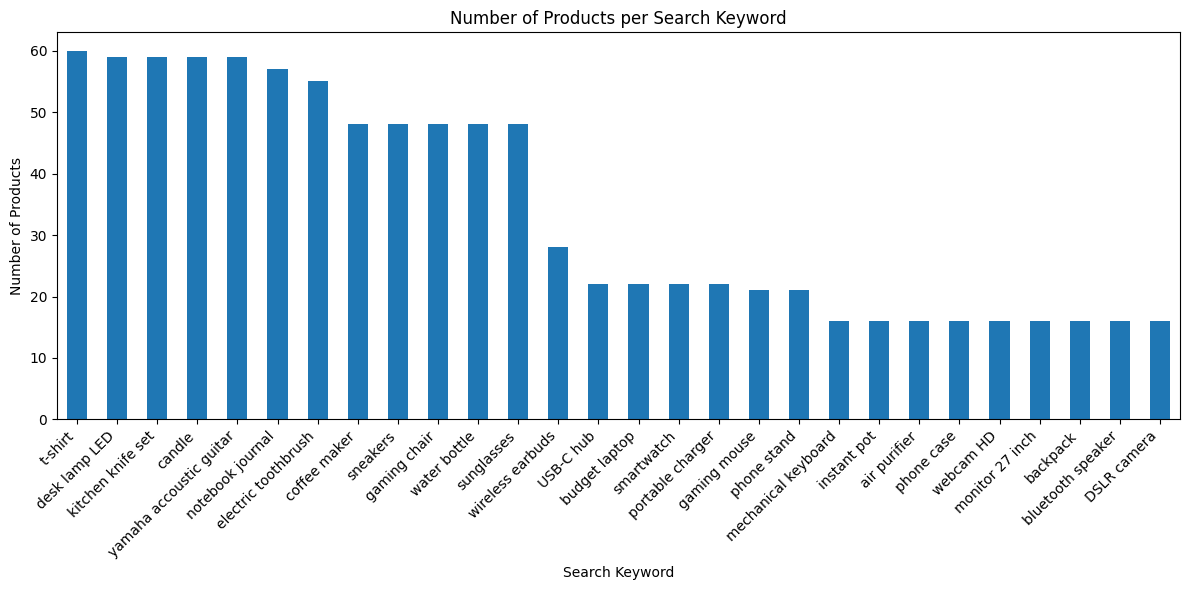

In [19]:
#Cell 16 — Keyword Distribution Chart
plt.figure(figsize=(12, 6))

keyword_counts.plot(
    kind="bar"
)

plt.title(
    "Number of Products per Search Keyword"
)

plt.xlabel(
    "Search Keyword"
)

plt.ylabel(
    "Number of Products"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

In [20]:
#Cell 17 — Check Product Number Integrity

expected_numbers = set(range(1, len(df) + 1))
actual_numbers = set(df["product_number"])

missing_numbers = expected_numbers - actual_numbers
extra_numbers = actual_numbers - expected_numbers

print("PRODUCT NUMBER VALIDATION")
print("-" * 50)

print(f"Minimum product number: {df['product_number'].min()}")
print(f"Maximum product number: {df['product_number'].max()}")
print(f"Unique product numbers: {df['product_number'].nunique()}")

print(f"\nMissing numbers: {len(missing_numbers)}")
print(f"Unexpected numbers: {len(extra_numbers)}")

print(
    f"Duplicate product numbers: "
    f"{df.duplicated(subset=['product_number']).sum()}"
)

PRODUCT NUMBER VALIDATION
--------------------------------------------------
Minimum product number: 1
Maximum product number: 950
Unique product numbers: 950

Missing numbers: 0
Unexpected numbers: 0
Duplicate product numbers: 0


In [21]:
#Cell 18 — Validate Price
print("PRICE VALIDATION")
print("-" * 50)

print(df["price"].describe())

invalid_price = df[
    (df["price"].isna()) |
    (df["price"] <= 0)
]

print(f"\nProducts with invalid price: {len(invalid_price)}")

if len(invalid_price) > 0:
    display(
        invalid_price[
            ["product_number", "asin", "title", "price"]
        ].head(10)
    )

PRICE VALIDATION
--------------------------------------------------
count     950.000000
mean       78.848137
std       115.292380
min         0.000000
25%        18.225000
50%        34.995000
75%        93.860000
max      1296.950000
Name: price, dtype: float64

Products with invalid price: 14


,product_number,asin,title,price
48,49,B0CW25XR5S,Razer Viper V3 Pro Wireless Esports Gaming Mou...,0.0
256,257,B0B5HRWH1S,Oral-B iO Series 3 Limited Deep Clean Recharge...,0.0
602,603,B07XLTPC5L,"Gildan Men's Crew T-Shirts, Multipack, Style G...",0.0
603,604,B086KY66PJ,"Hanes Men's Undershirt Packs, Stay-Tucked Soft...",0.0
605,606,B011QQE1HE,"Gildan Men's Crew T-Shirts, Multipack, Style G...",0.0
612,613,B07JBS59X1,"Gildan Men's Crew T-Shirts, Multipack, Style G...",0.0
613,614,B0D2PKRQSN,Hanes Men's Pocket T-Shirts - 6-Pack - Cotton ...,0.0
614,615,B00HVW5FQO,"Hanes Men's Undershirt Packs, Stay-Tucked Soft...",0.0
615,616,B00LSRU2JS,"Hanes Men's Undershirts T-Shirt Pack, V-Neck C...",0.0
636,637,B08F2NB5PH,"Fruit of The Loom Mens Pocket Tee Undershirts,...",0.0


In [22]:
#Cell 19 — Validate Average Ratings
print("AVERAGE RATING VALIDATION")
print("-" * 50)

print(df["average_rating"].describe())

invalid_ratings = df[
    (df["average_rating"] < 0) |
    (df["average_rating"] > 5) |
    (df["average_rating"].isna())
]

print(f"\nInvalid ratings found: {len(invalid_ratings)}")

if len(invalid_ratings) > 0:
    display(
        invalid_ratings[
            [
                "product_number",
                "asin",
                "title",
                "average_rating"
            ]
        ]
    )

AVERAGE RATING VALIDATION
--------------------------------------------------
count    950.000000
mean       4.464737
std        0.345997
min        0.000000
25%        4.400000
50%        4.500000
75%        4.600000
max        5.000000
Name: average_rating, dtype: float64

Invalid ratings found: 0


In [23]:
#Cell 20 — Validate Review Counts
print("REVIEW COUNT VALIDATION")
print("-" * 50)

print(df["review_count"].describe())

invalid_review_counts = df[
    (df["review_count"] < 0) |
    (df["review_count"].isna())
]

zero_review_counts = df[
    df["review_count"] == 0
]

print(
    f"\nInvalid review counts: "
    f"{len(invalid_review_counts)}"
)

print(
    f"Products with review_count = 0: "
    f"{len(zero_review_counts)}"
)

REVIEW COUNT VALIDATION
--------------------------------------------------
count       950.000000
mean      13939.554737
std       35189.765736
min           0.000000
25%         450.500000
50%        2110.500000
75%        9565.500000
max      334337.000000
Name: review_count, dtype: float64

Invalid review counts: 0
Products with review_count = 0: 3


In [24]:
#Cell 21 — Validate Required URLs
def is_valid_url(value):
    """Basic URL format validation."""

    if pd.isna(value):
        return False

    value = str(value).strip()

    return value.startswith(
        ("http://", "https://")
    )


url_columns = [
    "url",
    "image",
    "video_url",
]

print("URL VALIDATION")
print("-" * 50)

for column in url_columns:

    valid_count = df[column].apply(
        is_valid_url
    ).sum()

    missing_count = df[column].isna().sum()

    invalid_count = (
        len(df)
        - valid_count
        - missing_count
    )

    print(f"\n{column}:")
    print(f"  Valid URLs: {valid_count}")
    print(f"  Missing: {missing_count}")
    print(f"  Invalid format: {invalid_count}")

URL VALIDATION
--------------------------------------------------

url:
  Valid URLs: 950
  Missing: 0
  Invalid format: 0

image:
  Valid URLs: 950
  Missing: 0
  Invalid format: 0

video_url:
  Valid URLs: 937
  Missing: 13
  Invalid format: 0


In [25]:
#Cell 22 — Examine Missing Descriptions
missing_descriptions = df[
    df["description"].isna()
]

print(
    f"Products with missing descriptions: "
    f"{len(missing_descriptions)}"
)

display(
    missing_descriptions[
        [
            "product_number",
            "search_keyword",
            "title",
            "brand",
        ]
    ].head(10)
)

Products with missing descriptions: 72


,product_number,search_keyword,title,brand
532,533,backpack,abshoo Large Heavy Duty Backpack For School Co...,abshoo
599,600,t-shirt,SAMPEEL Crop Tops for Women Summer Trendy Tigh...,Sampeel
600,601,t-shirt,COOFANDY Mens Long Sleeve T Shirts Crew Neck C...,COOFANDY
601,602,t-shirt,Men's Cotton T-Shirts Oversized Unisex Short S...,KEEPSHOWING
607,608,t-shirt,Trendy Queen Womens Oversized T-Shirts Short S...,Trendy Queen
608,609,t-shirt,Girls Shirts Raglan Striped Short Sleeve Tops,GNKVLER
609,610,t-shirt,Hawaiian Shirts for Women Palm Trees Beach Gra...,OJLPHH
610,611,t-shirt,Runcati Mens Big and Tall Short Sleeve Crew Ne...,Runcati
619,620,t-shirt,"Boys T-Shirts 5 Pack,100% Cotton Jersey Short ...",Avsead
620,621,t-shirt,5 Pack Men's Dry Fit T Shirts Athletic Running...,Brand: AKAWOOKO


In [26]:
#Cell 23 — Missing Descriptions by Search Keyword
missing_description_by_keyword = (
    missing_descriptions
    .groupby("search_keyword")
    .size()
    .sort_values(ascending=False)
)

missing_description_by_keyword

,0
search_keyword,
sunglasses,29
t-shirt,27
sneakers,14
backpack,1
notebook journal,1


In [27]:
#Cell 24 — Examine Missing Brands
missing_brands = df[
    df["brand"].isna()
]

print(
    f"Products with missing brands: "
    f"{len(missing_brands)}"
)

display(
    missing_brands[
        [
            "product_number",
            "search_keyword",
            "title",
            "description",
        ]
    ].head(10)
)

Products with missing brands: 162


,product_number,search_keyword,title,description
7,8,wireless earbuds,"Soundcore by Anker P20i True Wireless Earbuds,...",About this item\r\nPowerful Bass: soundcore P2...
15,16,wireless earbuds,Sony WF-C510 Truly Wireless Bluetooth Earbud H...,Let your music live longer. Colorful and compa...
17,18,wireless earbuds,Samsung Galaxy Buds 4 Pro (2026) AI True Wirel...,"Audio lovers, the rich listening experience yo..."
18,19,wireless earbuds,Samsung Galaxy Buds Core SM-R410 (2025) | Lati...,Experience premium wireless audio with these S...
29,30,gaming mouse,"Acer Wired Gaming Mouse, 12,800 DPI RGB Ergono...",About this item\r\n【Balanced Weight & Mid-Hand...
30,31,gaming mouse,Logitech G305 Lightspeed Wireless Gaming Mouse...,Play advanced without wires or limits. The Log...
31,32,gaming mouse,Logitech G502 Hero Wired Gaming Mouse - Black ...,Logitech updated its iconic G502 gaming mouse ...
32,33,gaming mouse,Logitech G PRO X2 SUPERSTRIKE Wireless Gaming ...,Logitech G partnered with top esports athletes...
33,34,gaming mouse,Razer Basilisk V3 Customizable RGB Wired Ergon...,"Create, control, and champion your playstyle w..."
36,37,gaming mouse,Logitech MX Master 4 Ergonomic Wireless Mouse ...,The Logitech MX Master 4 brings immersive cont...


In [28]:
#Cell 25 — Missing Brands by Search Keyword
missing_brand_by_keyword = (
    missing_brands
    .groupby("search_keyword")
    .size()
    .sort_values(ascending=False)
)

missing_brand_by_keyword

,0
search_keyword,
water bottle,19
gaming mouse,17
yamaha accoustic guitar,16
coffee maker,12
sunglasses,11
webcam HD,11
monitor 27 inch,10
DSLR camera,10
smartwatch,8


In [29]:
#Cell 26 — Create Safe Review Parser
def parse_reviews(value):
    """
    Safely parse reviews stored as a JSON string.

    Returns an empty list if parsing fails.
    """

    if pd.isna(value):
        return []

    if isinstance(value, list):
        return value

    try:
        parsed = json.loads(value)

        if isinstance(parsed, list):
            return parsed

        return []

    except (json.JSONDecodeError, TypeError):
        return []

In [30]:
#Cell 27 — Test Review Parsing
sample_reviews = parse_reviews(
    df["reviews"].iloc[0]
)

print(type(sample_reviews))
print(f"Number of reviews: {len(sample_reviews)}")

if sample_reviews:
    print("\nFirst review:")
    print(
        json.dumps(
            sample_reviews[0],
            indent=4
        )
    )

<class 'list'>
Number of reviews: 8

First review:
{
    "reviewer_name": "Needsmorenails",
    "star_rating": 5.0,
    "review_title": "Durable, Excellent sound, Great value",
    "review_description": "While not a user of these earbuds, personally, I gave them as gifts to several people. When I asked how the earbuds were doing, I was told that the sound quality from them was way better than was expected. Deep Bass, crisp highs, and good imaging were some of the things said about these earbuds. One person remarked at how well they fit the ears and appreciated the loop to hook them on the ear as it helped them stay in place while engaging in outdoor activities. These earbuds have been white-water rafting, camping, hiking, mountain-biking, zip-lining, kayaking, rock-climbing, jogging, fishing, hunting, go-karting, and more. They are durable. They are also easy to clean and the functionality is ideal. They seem to keep a charge for more than a day and charge up quickly in their case. Non

In [31]:
#Cell 28 — Parse All Reviews
df["parsed_reviews"] = df[
    "reviews"
].apply(parse_reviews)

print("Reviews parsed successfully.")

Reviews parsed successfully.


In [32]:
#Cell 29 — Count Reviews Per Product
df["collected_review_count"] = df[
    "parsed_reviews"
].apply(len)

print(
    df["collected_review_count"]
    .describe()
)

count    950.000000
mean       7.888421
std        0.812295
min        0.000000
25%        8.000000
50%        8.000000
75%        8.000000
max        8.000000
Name: collected_review_count, dtype: float64


In [33]:
#Cell 30 — Review Collection Distribution
review_distribution = (
    df["collected_review_count"]
    .value_counts()
    .sort_index()
)

review_distribution

,count
collected_review_count,
0,4
1,5
2,1
3,1
4,1
5,5
6,3
7,3
8,927


In [34]:
#Cell 31 — Products With No Collected Reviews
no_reviews = df[
    df["collected_review_count"] == 0
]

print(
    f"Products with zero collected reviews: "
    f"{len(no_reviews)}"
)

if len(no_reviews) > 0:
    display(
        no_reviews[
            [
                "product_number",
                "asin",
                "search_keyword",
                "title",
                "review_count",
            ]
        ].head(20)
    )

Products with zero collected reviews: 4


,product_number,asin,search_keyword,title,review_count
5,6,B0G7H6K1WN,wireless earbuds,"Wireless Earbuds,Bluetooth 5.4 Ear buds,Sport ...",358
101,102,B0HDT8JNMC,smartwatch,"Smart Watch for Men Women Answer/Make Call, 1....",0
182,183,B0H1FLGRRR,desk lamp LED,"LED Desk Lamp with RGB Ambient Light, Dual Hea...",0
947,948,B0H4HT65QL,yamaha accoustic guitar,Pyle,0


In [35]:
#Cell 32 — Validate Review Structure
required_review_fields = {
    "reviewer_name",
    "star_rating",
    "review_title",
    "review_description",
}

invalid_review_records = []

for product_index, reviews in enumerate(
    df["parsed_reviews"]
):

    for review_index, review in enumerate(reviews):

        if not isinstance(review, dict):

            invalid_review_records.append(
                {
                    "product_index": product_index,
                    "review_index": review_index,
                    "issue": "Review is not a dictionary",
                }
            )

            continue

        missing_fields = (
            required_review_fields
            - set(review.keys())
        )

        if missing_fields:

            invalid_review_records.append(
                {
                    "product_index": product_index,
                    "review_index": review_index,
                    "issue": (
                        f"Missing fields: "
                        f"{missing_fields}"
                    ),
                }
            )

print(
    f"Invalid review records found: "
    f"{len(invalid_review_records)}"
)

Invalid review records found: 0


#Section 2 — Data Cleaning

In [36]:
#Check Database shape
df.shape

(950, 15)

In [37]:
df.head(1)


,product_number,asin,search_keyword,title,url,price,description,brand,image,review_count,average_rating,video_url,reviews,parsed_reviews,collected_review_count
0,1,B0HCNYJM8Z,wireless earbuds,"Wireless Sports Earbuds with Secure Earhooks, ...",https://www.amazon.com/Wireless-Sports-Earbuds...,25.99,About this item\r\nSecure Fit for High-Intensi...,Csasan,https://m.media-amazon.com/images/I/613tyoH+sm...,9662,4.4,https://m.media-amazon.com/images/S/vse-vms-tr...,"[{""reviewer_name"": ""Needsmorenails"", ""star_rat...","[{'reviewer_name': 'Needsmorenails', 'star_rat...",8


In [38]:
# Drop 'parsed_reviews' and 'collected_review_count' columns in-place
df.drop(columns=["parsed_reviews", "collected_review_count"], inplace=True)

In [39]:
df.head(1)

,product_number,asin,search_keyword,title,url,price,description,brand,image,review_count,average_rating,video_url,reviews
0,1,B0HCNYJM8Z,wireless earbuds,"Wireless Sports Earbuds with Secure Earhooks, ...",https://www.amazon.com/Wireless-Sports-Earbuds...,25.99,About this item\r\nSecure Fit for High-Intensi...,Csasan,https://m.media-amazon.com/images/I/613tyoH+sm...,9662,4.4,https://m.media-amazon.com/images/S/vse-vms-tr...,"[{""reviewer_name"": ""Needsmorenails"", ""star_rat..."


##2.1 Create a cleaning copy

In [40]:
# Create a copy of the raw dataset
df_clean = df.copy()

print("Original dataset shape:", df_clean.shape)

Original dataset shape: (950, 13)


##2.2 Remove products with no reviews

In [41]:
#Remove products with no reviews
import json
import numpy as np
def has_reviews(reviews_value):
    """
    Check whether a product contains at least one review.
    """

    try:
        reviews = json.loads(reviews_value)

        return isinstance(reviews, list) and len(reviews) > 0

    except (json.JSONDecodeError, TypeError):
        return False

df_clean["has_reviews"] = df_clean["reviews"].apply(has_reviews)

no_review_products = df_clean[
    ~df_clean["has_reviews"]
]

print("Products with no reviews:")
print(len(no_review_products))

no_review_products[
    [
        "product_number",
        "asin",
        "search_keyword",
        "title"
    ]
]

Products with no reviews:
4


,product_number,asin,search_keyword,title
5,6,B0G7H6K1WN,wireless earbuds,"Wireless Earbuds,Bluetooth 5.4 Ear buds,Sport ..."
101,102,B0HDT8JNMC,smartwatch,"Smart Watch for Men Women Answer/Make Call, 1...."
182,183,B0H1FLGRRR,desk lamp LED,"LED Desk Lamp with RGB Ambient Light, Dual Hea..."
947,948,B0H4HT65QL,yamaha accoustic guitar,Pyle


In [42]:
#Now remove them
df_clean = df_clean[
    df_clean["has_reviews"]
].copy()

# Remove temporary column
df_clean.drop(
    columns=["has_reviews"],
    inplace=True
)

print(
    "Dataset shape after removing products without reviews:",
    df_clean.shape
)

Dataset shape after removing products without reviews: (946, 13)


##2.3 Handle missing brand names

In [43]:
#Handle missing brand names
missing_brand_before = df_clean["brand"].isna().sum()

df_clean["brand"] = (
    df_clean["brand"]
    .fillna("No Brand")
)

missing_brand_after = df_clean["brand"].isna().sum()

print(
    f"Missing brands before: {missing_brand_before}"
)

print(
    f"Missing brands after: {missing_brand_after}"
)

Missing brands before: 162
Missing brands after: 0


In [44]:
#handle empty strings
df_clean["brand"] = (
    df_clean["brand"]
    .replace("", np.nan)
    .fillna("No Brand")
)

##2.4 Handle invalid prices using category median

In [45]:
#identify invalid prices.
invalid_price_mask = df_clean["price"] <= 0

print(
    "Invalid prices:",
    invalid_price_mask.sum()
)

Invalid prices: 14


In [46]:
#Calculate the median price for each search keyword
keyword_price_median = (
    df_clean[df_clean["price"] > 0]
    .groupby("search_keyword")["price"]
    .median()
)

keyword_price_median

,price
search_keyword,
DSLR camera,494.495
USB-C hub,23.585
air purifier,95.990
backpack,29.990
bluetooth speaker,42.950
budget laptop,266.340
candle,19.990
coffee maker,63.990
desk lamp LED,26.490


In [47]:
#Now impute zero prices
def impute_price(row):
    """
    Replace invalid price with the median valid price
    of products from the same search keyword.
    """

    if row["price"] <= 0:

        return keyword_price_median.get(
            row["search_keyword"],
            np.nan
        )

    return row["price"]

In [48]:
df_clean["price"] = df_clean.apply(
    impute_price,
    axis=1
)

In [49]:
#Validate
print(
    "Remaining invalid prices:",
    (df_clean["price"] <= 0).sum()
)

print(
    "Missing prices after imputation:",
    df_clean["price"].isna().sum()
)

Remaining invalid prices: 0
Missing prices after imputation: 0


In [50]:
#Show imputed products
imputed_price_products = df[
    df["price"] <= 0
][
    [
        "product_number",
        "asin",
        "search_keyword",
        "title",
        "price"
    ]
].copy()

imputed_price_products["new_price"] = (
    imputed_price_products["search_keyword"]
    .map(keyword_price_median)
)

imputed_price_products

,product_number,asin,search_keyword,title,price,new_price
48,49,B0CW25XR5S,gaming mouse,Razer Viper V3 Pro Wireless Esports Gaming Mou...,0.0,45.895
256,257,B0B5HRWH1S,electric toothbrush,Oral-B iO Series 3 Limited Deep Clean Recharge...,0.0,49.990
602,603,B07XLTPC5L,t-shirt,"Gildan Men's Crew T-Shirts, Multipack, Style G...",0.0,14.990
603,604,B086KY66PJ,t-shirt,"Hanes Men's Undershirt Packs, Stay-Tucked Soft...",0.0,14.990
605,606,B011QQE1HE,t-shirt,"Gildan Men's Crew T-Shirts, Multipack, Style G...",0.0,14.990
612,613,B07JBS59X1,t-shirt,"Gildan Men's Crew T-Shirts, Multipack, Style G...",0.0,14.990
613,614,B0D2PKRQSN,t-shirt,Hanes Men's Pocket T-Shirts - 6-Pack - Cotton ...,0.0,14.990
614,615,B00HVW5FQO,t-shirt,"Hanes Men's Undershirt Packs, Stay-Tucked Soft...",0.0,14.990
615,616,B00LSRU2JS,t-shirt,"Hanes Men's Undershirts T-Shirt Pack, V-Neck C...",0.0,14.990
636,637,B08F2NB5PH,t-shirt,"Fruit of The Loom Mens Pocket Tee Undershirts,...",0.0,14.990


##2.5 Handle missing descriptions

In [51]:
#Step 1: Check missing descriptions
missing_description_mask = (
    df_clean["description"].isna()
    |
    df_clean["description"].astype(str).str.strip().eq("")
)

print(
    "Products with missing descriptions:",
    missing_description_mask.sum()
)

display(
    df_clean.loc[
        missing_description_mask,
        [
            "product_number",
            "asin",
            "search_keyword",
            "title",
            "brand",
            "description",
        ],
    ].head(10)
)

Products with missing descriptions: 72


,product_number,asin,search_keyword,title,brand,description
532,533,B0F83YR84S,backpack,abshoo Large Heavy Duty Backpack For School Co...,abshoo,NaN
599,600,B0CNSHYZF7,t-shirt,SAMPEEL Crop Tops for Women Summer Trendy Tigh...,Sampeel,NaN
600,601,B0F9P8SJXJ,t-shirt,COOFANDY Mens Long Sleeve T Shirts Crew Neck C...,COOFANDY,NaN
601,602,B0C1Z64LJR,t-shirt,Men's Cotton T-Shirts Oversized Unisex Short S...,KEEPSHOWING,NaN
607,608,B0BPYCHYP9,t-shirt,Trendy Queen Womens Oversized T-Shirts Short S...,Trendy Queen,NaN
608,609,B0H9L8GN8D,t-shirt,Girls Shirts Raglan Striped Short Sleeve Tops,GNKVLER,NaN
609,610,B0C6MGY1Q1,t-shirt,Hawaiian Shirts for Women Palm Trees Beach Gra...,OJLPHH,NaN
610,611,B0FS7F8P89,t-shirt,Runcati Mens Big and Tall Short Sleeve Crew Ne...,Runcati,NaN
619,620,B0GC59R2B4,t-shirt,"Boys T-Shirts 5 Pack,100% Cotton Jersey Short ...",Avsead,NaN
620,621,B09B5BQ3YX,t-shirt,5 Pack Men's Dry Fit T Shirts Athletic Running...,Brand: AKAWOOKO,NaN


In [52]:
#Step 2: Create a flag before imputation
df_clean["description_imputed"] = missing_description_mask

In [53]:
#Step 3: Create fallback descriptions
def generate_fallback_description(row):
    """
    Generate a fallback description for products
    with missing descriptions using available
    product metadata.
    """

    brand = row["brand"]

    if pd.isna(brand) or str(brand).strip() == "":
        brand = "No Brand"

    return (
        f"{row['title']} is a product from {brand} "
        f"in the {row['search_keyword']} category."
    )

In [54]:
#Step 4: Impute only missing descriptions
df_clean.loc[
    missing_description_mask,
    "description"
] = df_clean.loc[
    missing_description_mask
].apply(
    generate_fallback_description,
    axis=1,
)

In [55]:
#Step 5: Validate the result
missing_description_after = (
    df_clean["description"].isna().sum()
)

print(
    "Missing descriptions after imputation:",
    missing_description_after
)

print(
    "\nNumber of imputed descriptions:",
    df_clean["description_imputed"].sum()
)

Missing descriptions after imputation: 0

Number of imputed descriptions: 72


In [56]:
#Step 6: Inspect generated descriptions
display(
    df_clean[
        df_clean["description_imputed"]
    ][
        [
            "product_number",
            "title",
            "brand",
            "search_keyword",
            "description",
        ]
    ].head(10)
)

,product_number,title,brand,search_keyword,description
532,533,abshoo Large Heavy Duty Backpack For School Co...,abshoo,backpack,abshoo Large Heavy Duty Backpack For School Co...
599,600,SAMPEEL Crop Tops for Women Summer Trendy Tigh...,Sampeel,t-shirt,SAMPEEL Crop Tops for Women Summer Trendy Tigh...
600,601,COOFANDY Mens Long Sleeve T Shirts Crew Neck C...,COOFANDY,t-shirt,COOFANDY Mens Long Sleeve T Shirts Crew Neck C...
601,602,Men's Cotton T-Shirts Oversized Unisex Short S...,KEEPSHOWING,t-shirt,Men's Cotton T-Shirts Oversized Unisex Short S...
607,608,Trendy Queen Womens Oversized T-Shirts Short S...,Trendy Queen,t-shirt,Trendy Queen Womens Oversized T-Shirts Short S...
608,609,Girls Shirts Raglan Striped Short Sleeve Tops,GNKVLER,t-shirt,Girls Shirts Raglan Striped Short Sleeve Tops ...
609,610,Hawaiian Shirts for Women Palm Trees Beach Gra...,OJLPHH,t-shirt,Hawaiian Shirts for Women Palm Trees Beach Gra...
610,611,Runcati Mens Big and Tall Short Sleeve Crew Ne...,Runcati,t-shirt,Runcati Mens Big and Tall Short Sleeve Crew Ne...
619,620,"Boys T-Shirts 5 Pack,100% Cotton Jersey Short ...",Avsead,t-shirt,"Boys T-Shirts 5 Pack,100% Cotton Jersey Short ..."
620,621,5 Pack Men's Dry Fit T Shirts Athletic Running...,Brand: AKAWOOKO,t-shirt,5 Pack Men's Dry Fit T Shirts Athletic Running...


#Section 3: Post-Cleaning Validation
This section validates that the cleaning operations were successfully applied and checks the final dataset quality before feature-specific preprocessing.

In [57]:
#Dataset summary
print("=" * 60)
print("POST-CLEANING DATASET SUMMARY")
print("=" * 60)

print(f"Total rows: {df_clean.shape[0]}")
print(f"Total columns: {df_clean.shape[1]}")

print(f"\nUnique ASINs: {df_clean['asin'].nunique()}")
print(
    f"Duplicate ASINs: "
    f"{df_clean['asin'].duplicated().sum()}"
)

POST-CLEANING DATASET SUMMARY
Total rows: 946
Total columns: 14

Unique ASINs: 946
Duplicate ASINs: 0


In [58]:
#Missing values
print("MISSING VALUES")
print("-" * 40)

missing_summary = pd.DataFrame({
    "missing_count": df_clean.isnull().sum(),
    "missing_percentage": (
        df_clean.isnull().sum()
        / len(df_clean)
        * 100
    ).round(2)
})

missing_summary = (
    missing_summary[
        missing_summary["missing_count"] > 0
    ]
    .sort_values(
        by="missing_count",
        ascending=False
    )
)

display(missing_summary)

MISSING VALUES
----------------------------------------


,missing_count,missing_percentage
video_url,12,1.27


In [59]:
#Validate prices
print("PRICE VALIDATION")
print("-" * 40)

invalid_prices = df_clean[
    df_clean["price"] <= 0
]

print(
    f"Products with invalid prices: "
    f"{len(invalid_prices)}"
)

print("\nPrice statistics:")
display(
    df_clean["price"].describe()
)

PRICE VALIDATION
----------------------------------------
Products with invalid prices: 0

Price statistics:


,price
count,946.000000
mean,79.388568
std,115.299683
min,2.970000
25%,18.717500
50%,35.850000
75%,94.702500
max,1296.950000


In [60]:
#Validate reviews
def get_review_count(reviews_value):
    """Return the number of reviews in a reviews JSON string."""

    try:
        reviews = json.loads(reviews_value)

        if isinstance(reviews, list):
            return len(reviews)

        return 0

    except (json.JSONDecodeError, TypeError):
        return 0

In [61]:
df_clean["review_number_collected"] = (
    df_clean["reviews"]
    .apply(get_review_count)
)

print("REVIEW VALIDATION")
print("-" * 40)

print(
    "Products with zero collected reviews:",
    (df_clean["review_number_collected"] == 0).sum()
)

print("\nCollected review count statistics:")
display(
    df_clean["review_number_collected"]
    .describe()
)

REVIEW VALIDATION
----------------------------------------
Products with zero collected reviews: 0

Collected review count statistics:


,review_number_collected
count,946.000000
mean,7.921776
std,0.630957
min,1.000000
25%,8.000000
50%,8.000000
75%,8.000000
max,8.000000


#Section 4: General Feature Engineering

In [62]:
#Text length features
df_clean["title_length"] = (
    df_clean["title"]
    .fillna("")
    .str.len()
)

df_clean["description_length"] = (
    df_clean["description"]
    .fillna("")
    .str.len()
)

print(
    df_clean[
        [
            "title_length",
            "description_length",
            "review_number_collected",
        ]
    ].describe()
)

       title_length  description_length  review_number_collected
count    946.000000          946.000000               946.000000
mean     147.949260         1166.694503                 7.921776
std       58.085064          753.206182                 0.630957
min        4.000000            1.000000                 1.000000
25%      116.000000          526.500000                 8.000000
50%      174.000000         1124.500000                 8.000000
75%      193.000000         1633.000000                 8.000000
max      208.000000         4147.000000                 8.000000


#Section 5: Final Dataset Overview


In [63]:
print("=" * 60)
print("FINAL CLEANED DATASET")
print("=" * 60)

print(f"Rows: {df_clean.shape[0]}")
print(f"Columns: {df_clean.shape[1]}")

print("\nColumns:")
for column in df_clean.columns:
    print(f" - {column}")

print("\nData types:")
display(df_clean.dtypes)

print("\nFinal missing values:")
display(
    df_clean.isnull()
    .sum()
    .sort_values(ascending=False)
)

FINAL CLEANED DATASET
Rows: 946
Columns: 17

Columns:
 - product_number
 - asin
 - search_keyword
 - title
 - url
 - price
 - description
 - brand
 - image
 - review_count
 - average_rating
 - video_url
 - reviews
 - description_imputed
 - review_number_collected
 - title_length
 - description_length

Data types:


,0
product_number,int64
asin,object
search_keyword,object
title,object
url,object
price,float64
description,object
brand,object
image,object
review_count,int64



Final missing values:


,0
video_url,12
product_number,0
asin,0
title,0
search_keyword,0
price,0
description,0
brand,0
url,0
image,0


#Section 6: Export Cleaned Dataset

In [64]:
final_columns = [
    "product_number",
    "asin",
    "search_keyword",
    "title",
    "url",
    "price",
    "description",
    "description_imputed",
    "brand",
    "image",
    "review_count",
    "average_rating",
    "video_url",
    "reviews",
    "review_number_collected",
    "title_length",
    "description_length",
]

df_clean = df_clean[final_columns]

In [65]:
output_filename = "cleaned_products.csv"

df_clean.to_csv(
    output_filename,
    index=False,
    encoding="utf-8"
)

print(
    f"Cleaned dataset saved successfully: "
    f"{output_filename}"
)

print(
    f"Final dataset shape: "
    f"{df_clean.shape}"
)

Cleaned dataset saved successfully: cleaned_products.csv
Final dataset shape: (946, 17)


In [66]:
from google.colab import files

files.download(output_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>